###### Installating Ansible  on Amazon Linux

In [ ]:
su bash  -- to shift to root user

In [ ]:
yum update -y

###### 1. Install Ansible using EPEL Repository

In [ ]:
Download epel repository on the amazon linux 2 instance as follows,

$ wget https://dl.fedoraproject.org/pub/epel/epel-release-latest-7.noarch.rpm

In [ ]:
Next, Install epel repository using yum.

$ sudo yum install epel-release-latest-7.noarch.rpm

In [ ]:
Update epel repository as follows,

$ sudo yum update -y

In [ ]:
Now install all individual packages inside the repository along with ansible.

$ sudo yum install python python-devel python-pip openssl ansible -y

###### 2. Install Ansible using amazon-linux-extras Repository

In [ ]:
Ansible package can be installed on amazon linux using amazon provided packages.

$ sudo amazon-linux-extras install ansible2

In [ ]:
Check Ansible version

To verify whether Ansible is installed on your machine, you can verify it as follows,

$ ansible --version

###### 3. Configure Ansible on Amazon Linux-2

In [ ]:
Firstly, create new users on master & client machines and perform all the below given operations 

$ useradd ansadmin

$ passwd ansadmin

In [ ]:
Grant admin access to created user for master & client machines. 

You need login as root to make changes here.

We have added ansadmin user in sudoers file and enable authentication without password each time.

In [ ]:
visudo

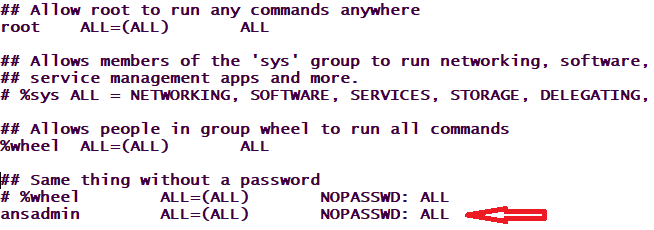

In [ ]:
Thereafter,Allow password authentication to yes 
so that ldap users can login using username & password on master & client machines.

In [ ]:
 vi /etc/ssh/sshd_config

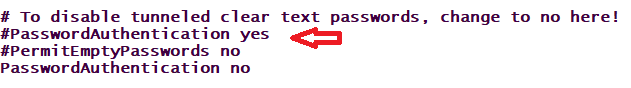

In [ ]:
Uncomment above highlighted line and enable password authentication to YES. Restart sshd service.

In [ ]:
service sshd restart

Note:- Perform the above operations in client machines with login as ansadmin. 

###### Managing inventory file on Master

In [ ]:
A default hosts file is created while ansible installation.
To manage your infrastructure you need to make entries of your available server machines in this hosts file.

$ sudo  vi /etc/ansible/hosts

In [ ]:
Insert client machines ip address into the inventory file:

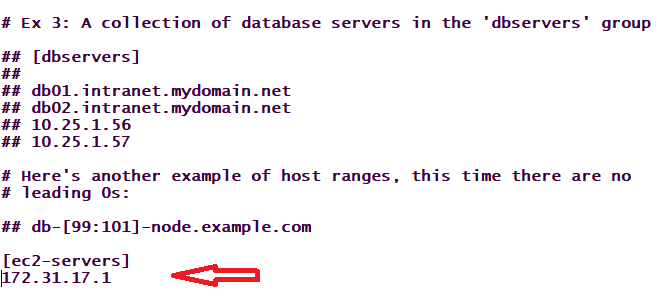

In [ ]:
Simply we put client machine ip address here. 
You can create custom inventory file if you do not want to use default hosts file.

###### Now Login as ansadmin user and generate public and private keys in Master machine.

In [ ]:
$ su ansadmin

$ cd home

$ cd ansadmin

$ ssh-keygen

Note:- In the below image, it is given as ansadmin@client-1 which is incorrect. We need to do it in Master Node. 

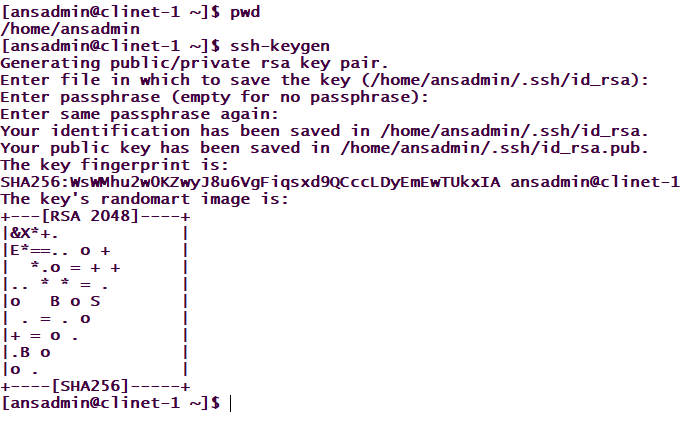

In [ ]:
Now you need to copy ssh keys from master to client machines.

First check the private ip address of the master node as follows,

In [ ]:
$ ifconfig -a

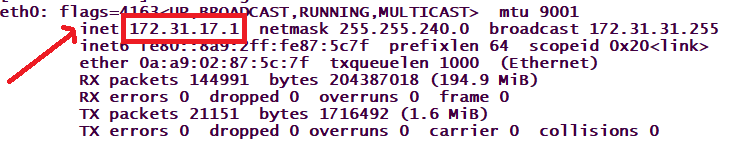

In [ ]:
Copy the public key file from client to master node.

$ cd .ssh

$ ls  (it will display id_rsa id_rsa.pub)

$ ssh-copy-id -i /home/ansadmin/.ssh/id_rsa.pub ansadmin@172.31.17.1 (Client Machine IP Address)

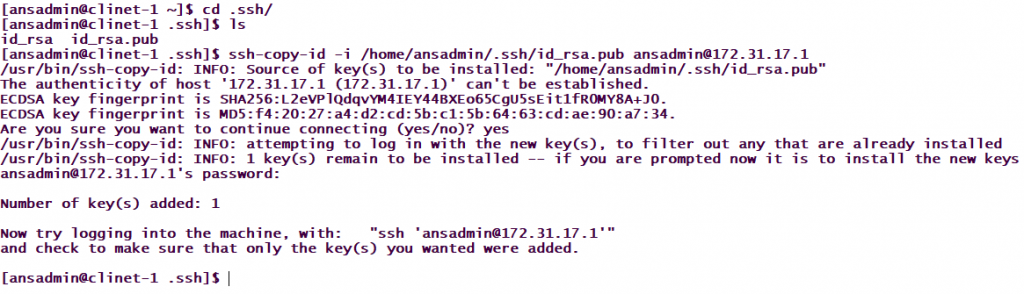

In [ ]:
To verify this, try to login to client machine from master using ssh method.

$ ssh ansadmin@172.31.17.2

It will ask password for the first time.

Next time it won’t ask password. 

Here, 172.31.17.2 is the private ip address of client node.

###### Perform Ping test from Master to Client machines

In [ ]:
Ansible contains various modules to manage IT infrastructure.  

Here, we will use ping module to check connection status between master and client node as follows,

$ ansible -m ping ec2-servers

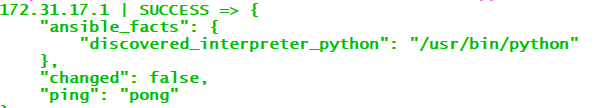

In [ ]:
Finally, client machine can be accessed from master node through ansible.

https://thecodecloud.in/ansible-installation-configuration-amazon-linux-ec2-instance-aws/